## Spatial Data Science (GIS6307/GEO4930)

---

# Lab 5 (Part A): Point Pattern Analysis (Descriptive Methods)

In this lab, you will use descriptive methods to analyze point patterns. Specifically, the following methods will be used.
Mean Center
- Standard Distance
- Standard Deviational Ellipse

This lab is modified from [Point Pattern Analysis](https://geographicdata.science/book/notebooks/08_point_pattern_analysis.html) in Rey, Arribas-Bel, and Wolf. (2020) [Geographic Data Science with Python](https://geographicdata.science/book/intro.html).

### `Due on Wednesday 3/2. Submit the completed Jupyter Notebook (.ipynb) in Canvas`

<br>
Instructor: Yi Qiang (qiangy@usf.edu)<br>
Teaching Assistant: Jinwen Xu (jinwenxu@usf.edu)


---

## 1. Install New Libraries

We will need a new library [pointpats](https://pointpats.readthedocs.io/en/latest/).

1. Please open Anaconda Prompt, and use the command `conda activate geo` to activate the "geo" environment that you created in the previous lab. 

2. Install pointpats using the following command:

    `conda install -c conda-forge pointpats`
    
    Click 'y' and then 'Enter' when asked to proceed.
    
3. Run the following code to import all packages needed in this lab.

In [142]:
import pointpats as ppt
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sbn
from matplotlib.patches import Ellipse, Circle
import matplotlib.pyplot as plt

#set default plot size, you can adjust the [width, height] to make plots fit your screen size
plt.rcParams['figure.figsize'] = [10, 10]

## 2. Read and Explore the Dataset

Read the dataset of geotagged Flickr photos (airbnb.csv) to a pandas DataFrame object. These photos are taken by Flickr users and shared in Flickr with public access. Geotagged Flickr photos are a typical example of geospatial big data that are crowdsourced from volunteer social media users.

In [68]:
# Read the file into a DataFrame
df = pd.read_csv("other/tokyo.csv")

# Preview the DataFrame
df.head()

,user_id,longitude,latitude,date_taken,photo/video_page_url,x,y
0,10727420@N00,139.700499,35.674000,2010-04-09 17:26:25.0,http://www.flickr.com/photos/10727420@N00/4545...,1.555139e+07,4.255856e+06
1,8819274@N04,139.766521,35.709095,2007-02-10 16:08:40.0,http://www.flickr.com/photos/8819274@N04/26503...,1.555874e+07,4.260667e+06
2,62068690@N00,139.765632,35.694482,2008-12-21 15:45:31.0,http://www.flickr.com/photos/62068690@N00/3125...,1.555864e+07,4.258664e+06
3,49503094041@N01,139.784391,35.548589,2011-11-11 05:48:54.0,http://www.flickr.com/photos/49503094041@N01/6...,1.556073e+07,4.238684e+06
4,40443199@N00,139.768753,35.671521,2006-04-06 16:42:49.0,http://www.flickr.com/photos/40443199@N00/2482...,1.555899e+07,4.255517e+06


Print URL of the first photo. You can copy and paste the url to your browser to view it.

In [83]:
df.loc[0]['photo/video_page_url']

'http://www.flickr.com/photos/10727420@N00/4545144774/'

Print data types of all columns in `df`

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10000 non-null  object 
 1   longitude             10000 non-null  float64
 2   latitude              10000 non-null  float64
 3   date_taken            10000 non-null  object 
 4   photo/video_page_url  10000 non-null  object 
 5   x                     10000 non-null  float64
 6   y                     10000 non-null  float64
dtypes: float64(4), object(3)
memory usage: 547.0+ KB


The `longitude` and `latitude` columns are coordinates in the geographic coordinate system (EPSG:4326). The `x` and `y` columns are coordinates in a projected coordinate system (UTM 35N zone). We will use the `x` and `y` coordinates to do spatial analysis.

## 3. Mean and Median Center

First, we use `seaborn.jointplot` to map locations of Flickr photos. The histograms at the edges show distribution of points along the x and y dimensions respectively.

Note: the basemap is added to `ax1.ax_joint`, which refers to the part inside the box.

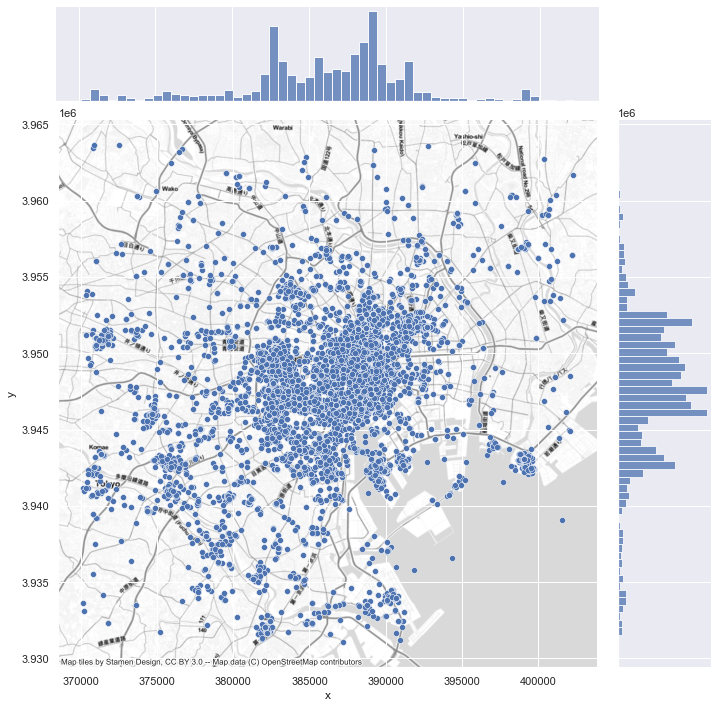

In [145]:
# Import contextily for the basemap
import contextily as cx

# Generate scatter plot for the flickr locations, using x and y as coordinates
ax1 = sbn.jointplot(x = df['x'], y = df['y'], height=10)

# Add a basemap to the 
cx.add_basemap(source = cx.providers.Stamen.TonerLite, crs="EPSG:3095", ax = ax1.ax_joint)

Select the `x` and `y` columns from df and store them in a new dataframe `pt`.

In [156]:
from pointpats import centrography

mean_center = centrography.mean_center(df[['x','y']])
med_center = centrography.euclidean_median(df[['x','y']])

Add the mean and median centers to the map.

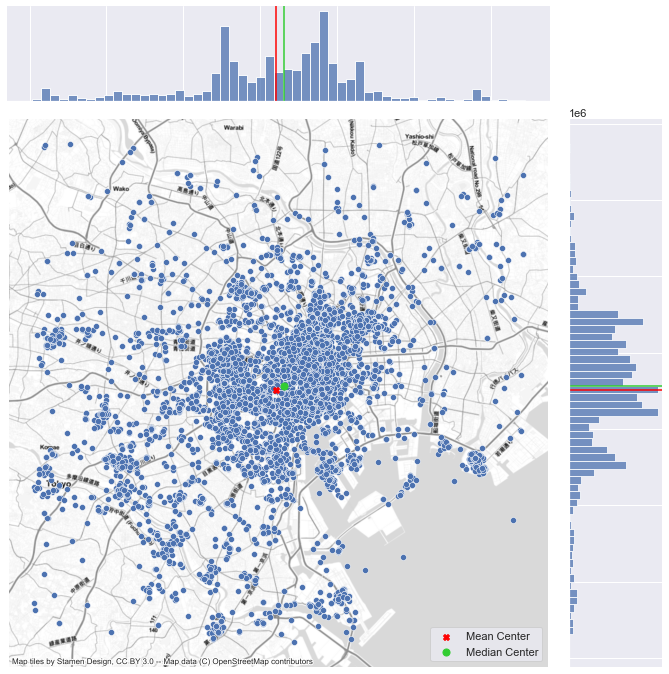

In [165]:
# 1. Generate scatter plot
ax1 = sbn.jointplot(x = df['x'], y = df['y'], height=10)

# 2. Add mean and median point
ax1.ax_joint.scatter(*mean_center, color='red', marker='X', label='Mean Center')
ax1.ax_joint.scatter(*med_center, color='limegreen', marker='o', s=50, label='Median Center')

# 3. Add marginal lines for mean point and median point
ax1.ax_marg_x.axvline(mean_center[0], color='red')
ax1.ax_marg_y.axhline(mean_center[1], color='red')
ax1.ax_marg_x.axvline(med_center[0], color='limegreen')
ax1.ax_marg_y.axhline(med_center[1], color='limegreen')

# 4. Legend
ax1.ax_joint.legend()

# 5. Add basemap
cx.add_basemap(source = cx.providers.Stamen.TonerLite, crs="EPSG:3095", ax = ax1.ax_joint)

# 6. Clean axes
ax1.ax_joint.set_axis_off()


The discrepancy between the two centers is caused by the skew; there are many “clusters” of pictures far out in West and South Tokyo, whereas North and East Tokyo is densely packed, but drops off very quickly. Thus, the far out clusters of pictures pulls the mean center to the west and south, relative to the median center.

## Standard Distance

A measure of dispersion that is common in centrography is the standard distance. This measure provides the average distance away from the center of the point cloud (such as measured by the center of mass). This is also simple to compute using pointpats, using the `std_distance` function.

In [167]:
centrography.std_distance(df[['x','y']])

7124.3055053566295

This means that, on average, pictures are taken around 7124 meters away from the mean center.

Another helpful visualization is the standard deviational ellipse, or standard ellipse. This is an ellipse drawn from the data that reflects its center, dispersion, and orientation. 

To visualize this, we first compute the axes and rotation using the ellipse function in pointpats:

In [173]:
major, minor, rotation = centrography.ellipse(df[['x','y']])

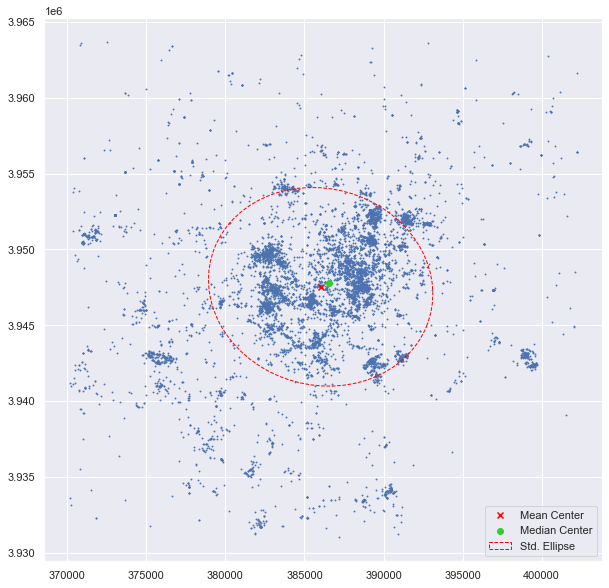

In [178]:
from matplotlib.patches import Ellipse

# Set up figure and axis
ax2 = plt.subplot()
# Plot photograph points
ax2.scatter(df['x'], df['y'], s=0.75)
ax2.scatter(*mean_center, color='red', marker='x', label='Mean Center')
ax2.scatter(*med_center, color='limegreen', marker='o', label='Median Center')

# Construct the standard ellipse using matplotlib
ellipse = Ellipse(xy=mean_center, # center the ellipse on our mean center
                  width=major*2, # centrography.ellipse only gives half the axis
                  height=minor*2, 
                  angle = np.rad2deg(rotation), # Angles for this are in degrees, not radians
                  facecolor='none', 
                  edgecolor='red', linestyle='--',
                  label='Std. Ellipse')
ax2.add_patch(ellipse)

ax2.legend()
# Display
# Add basemap
cx.add_basemap(source = cx.providers.Stamen.TonerLite, crs="EPSG:3095", ax = ax1.ax_joint)